# Dist3 (C3 スプリッタ) SM の受理ドメインと「谷」— なぜ r3 が最大の失敗か

**問い**: BO で最大の失敗カテゴリは **r3 (Dist3 SM の classifier が infeasible 判定, 全失敗の ~35%)**。
これは Dist3 SM(学習済み GaussianProcess + RandomForest classifier)の**受理ドメイン**と、
catofin フローが膜から渡す Dist3 フィードの**不一致**で起きる。本ノートでそれを可視化・定量化する。

Dist3 SM の入力 5 つ: `In_Total_Stages, In_Feed_Stage, In_Column_P[kPa], In_Flow[kgmol/s], In_Propane(C3H8分率)`。
学習域(`models/column3_sm.pkl` の bounds): In_Flow 0.361–0.5, In_Propane 0.05–0.20。
`_predict` は入力を bounds に clamp してから classifier で feasibility 判定する。HYSYS 不要(SM/分類器のみ)。


In [1]:
import os, sys, pickle
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

m = pickle.load(open(os.path.join(ROOT, 'models', 'column3_sm.pkl'), 'rb'))
cols = list(m['input_columns']); clf = m['classifier']; b = m['bounds']
print('input_columns :', cols)
print('In_Flow 学習域 :', tuple(round(x,3) for x in b['In_Flow']), 'kgmol/s')
print('In_Propane学習域:', b['In_Propane'])
print('training_rows :', m.get('training_rows'), ' feasible_rows :', m.get('feasible_rows'))

def clamp(x):
    y = dict(x)
    for c in cols:
        lo, hi = b[c]; y[c] = min(max(y[c], lo), hi)
    return y

def feas(N, P, flow, prop, fr=0.75):
    x = clamp({'In_Total_Stages': N, 'In_Feed_Stage': int(round(fr*N)),
               'In_Column_P': P, 'In_Flow': flow, 'In_Propane': prop})
    return bool(clf.predict(pd.DataFrame([[x[c] for c in cols]], columns=cols))[0])

C:\Users\yuish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


input_columns : ['In_Total_Stages', 'In_Feed_Stage', 'In_Column_P', 'In_Flow', 'In_Propane']
In_Flow 学習域 : (0.361, 0.5) kgmol/s
In_Propane学習域: (0.05, 0.2)
training_rows : 248  feasible_rows : 123


C:\Users\yuish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\yuish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\yuish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to 

## §1. classifier 受理面 (In_Flow × In_Propane)

N=137, P=1750kPa(設計点近傍)で、In_Flow と In_Propane を振って classifier の feasible 域を描く。
**catofin #227 が膜から渡す Dist3 フィード**(実測: In_Flow≈0.338, In_Propane≈0.039)を重ねる。


C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_28780\3148916965.py:18: UserWarning: Glyph 33180 (\N{CJK UNIFIED IDEOGRAPH-819C}) missing from font(s) DejaVu Sans.
  ax.legend(loc='upper right', fontsize=9); plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_28780\3148916965.py:18: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  ax.legend(loc='upper right', fontsize=9); plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_28780\3148916965.py:18: UserWarning: Glyph 36942 (\N{CJK UNIFIED IDEOGRAPH-904E}) missing from font(s) DejaVu Sans.
  ax.legend(loc='upper right', fontsize=9); plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_28780\3148916965.py:18: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  ax.legend(loc='upper right', fontsize=9); plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude

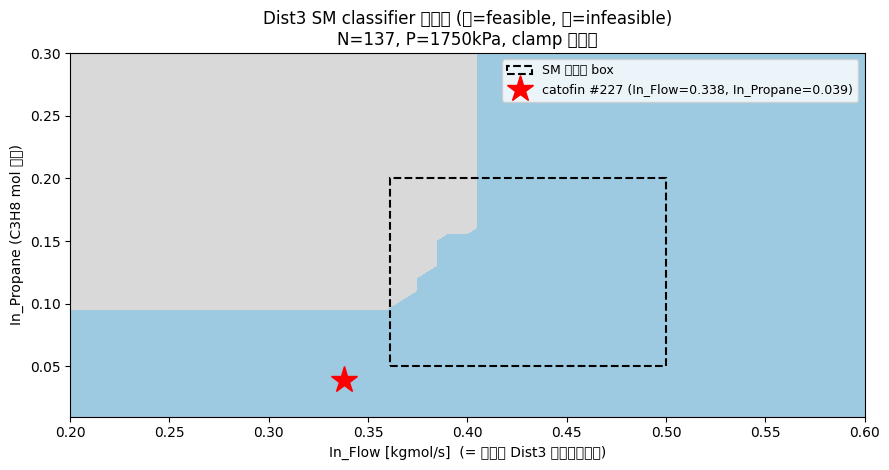

受理パターン (clamp 後):
  低流量 (In_Flow<=0.36): In_Propane<=0.05 の超高純度コーナーのみ受理
  高流量 (In_Flow>=0.43): In_Propane 不問で受理
  → 中流量×中propane の「谷」が NG。catofin #227 は低流量×超高純度コーナーでギリ通過。


In [2]:
flows = np.linspace(0.20, 0.60, 41)
props = np.linspace(0.01, 0.30, 30)
Z = np.array([[1 if feas(137, 1750, fl, pr) else 0 for fl in flows] for pr in props])

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.contourf(flows, props, Z, levels=[-0.5, 0.5, 1.5], colors=['0.85', '#9ecae1'])
ax.axvspan(b['In_Flow'][0], b['In_Flow'][1], ymin=0, ymax=1, color='none', ec='k', lw=0)
# 学習域ボックス
import matplotlib.patches as mp
ax.add_patch(mp.Rectangle((b['In_Flow'][0], b['In_Propane'][0]),
                          b['In_Flow'][1]-b['In_Flow'][0], b['In_Propane'][1]-b['In_Propane'][0],
                          fill=False, ec='k', ls='--', lw=1.5, label='SM 学習域 box'))
# catofin #227 の着地点
ax.plot(0.338, 0.039, 'r*', ms=20, label='catofin #227 (In_Flow=0.338, In_Propane=0.039)')
ax.set_xlabel('In_Flow [kgmol/s]  (= 膜透過 Dist3 フィード流量)')
ax.set_ylabel('In_Propane (C3H8 mol 分率)')
ax.set_title('Dist3 SM classifier 受理面 (青=feasible, 灰=infeasible)\nN=137, P=1750kPa, clamp 後判定')
ax.legend(loc='upper right', fontsize=9); plt.tight_layout(); plt.show()

print('受理パターン (clamp 後):')
print('  低流量 (In_Flow<=0.36): In_Propane<=0.05 の超高純度コーナーのみ受理')
print('  高流量 (In_Flow>=0.43): In_Propane 不問で受理')
print('  → 中流量×中propane の「谷」が NG。catofin #227 は低流量×超高純度コーナーでギリ通過。')

## §2. N・P 依存と「N=115 以下が弱い」

clamp 済み入力で、段数 N と 圧力 P を振って受理を見る(In_Flow/In_Propane は #227 近傍に固定)。


In [3]:
Ns = [115, 120, 125, 137, 150, 160]; Ps = [1600, 1700, 1750, 1800, 1900]
print('N \\ P   ' + '  '.join(f'{p:>5}' for p in Ps))
for N in Ns:
    row = '  '.join(' ok ' if feas(N, p, 0.338, 0.039) else ' NG ' for p in Ps)
    print(f'  {N:>3}   {row}')
print('\n→ #227 着地点(0.338/0.039)では N>=120 で受理。問題は N でなく In_Flow/In_Propane の谷。')

N \ P    1600   1700   1750   1800   1900
  115    ok    ok    ok    ok    ok 


  120    ok    ok    ok    ok    ok 
  125    ok    ok    ok    ok    ok 


  137    ok    ok    ok    ok    ok 
  150    ok    ok    ok    ok    ok 


  160    ok    ok    ok    ok    ok 

→ #227 着地点(0.338/0.039)では N>=120 で受理。問題は N でなく In_Flow/In_Propane の谷。


## §3. 結論と対処方向

- Dist3 SM の受理は **(a) In_Flow≥0.43(高流量, propane不問)** か **(b) 低流量×超高純度(In_Propane≤0.05)** の2択で、
  間の**谷(中流量×中propane)が NG**。谷は学習域の**内側**(= 学習時に HYSYS が収束しなかった実infeasible)。
- alpha=90 の高選択膜は permeate を C3H6 高純度(In_Propane≈0.039)に吐くため、catofin フローは
  **低流量×超高純度コーナー**に着地する。QMC で A_mem/F_fresh が散ると谷に落ち r3 失敗(~35%)。
- **対処**: (i) 膜 A_mem を可行窓(~120–180k)に絞り着地を安定化、(ii) ただし A_mem を動かすと Dist2 が
  逆戻りする連成あり(別途確認済)。谷は学習域内=実infeasible のため classifier を緩めるのは危険
  (外挿で偽 TAC を掴む)。Dist3 を rigorous 化すれば壁は消えるが N=137 微小α で遅い/収束難。

> 本ノートは SM/classifier のみ(HYSYS 不要)。受理面は `models/column3_sm.pkl` の学習結果。
